In [ ]:
# ==========================================================
# IMPORTAÇÃO DAS BIBLIOTECAS
# ==========================================================

# Manipulação de dados
import pandas as pd
import numpy as np

# Separação treino e teste
from sklearn.model_selection import train_test_split

# Conversão de variáveis categóricas para numéricas
from sklearn.preprocessing import LabelEncoder

# Modelo escolhido
from sklearn.ensemble import RandomForestClassifier

# Métricas de avaliação
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score
)

In [ ]:
# ==========================================================
# LEITURA DA BASE
# ==========================================================

# Carrega o arquivo CSV
df = pd.read_csv("/content/desafio_nps_fase_1.csv")

# Exibe quantidade de linhas e colunas
print("Dimensões da base:")
print(df.shape)

# Mostra as primeiras linhas
df.head()

Dimensões da base:
(2500, 19)


,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


In [ ]:
# ==========================================================
# DEFINIÇÃO DA VARIÁVEL ALVO (TARGET)
# ==========================================================

# Cliente é considerado detrator quando NPS <= 6
# 1 = detrator
# 0 = não detrator

df["is_detrator"] = (
    df["nps_score"] <= 6
).astype(int)

# Verifica distribuição da variável alvo
print("Distribuição do Target:")

df["is_detrator"].value_counts()

Distribuição do Target:


,count
is_detrator,
1,1851
0,649


In [ ]:
# ==========================================================
# REMOÇÃO DE COLUNAS COM RISCO DE DATA LEAKAGE
# ==========================================================

# Data leakage ocorre quando o modelo utiliza
# informações que não estariam disponíveis no momento
# da previsão.

colunas_remover = [

    # Identificadores sem valor preditivo
    "customer_id",
    "order_id",

    # Variável utilizada para criar o target
    "nps_score",

    # Informação posterior à compra
    "repeat_purchase_30d",

    # Forte indicador de satisfação
    "csat_internal_score"
]

for coluna in colunas_remover:

    if coluna in df.columns:

        df.drop(columns=coluna, inplace=True)

print("Nova dimensão da base:")
print(df.shape)

Nova dimensão da base:
(2500, 15)


In [ ]:
# ==========================================================
# FEATURE ENGINEERING
# ==========================================================

# Criação de novas variáveis com base nos
# principais insights encontrados na EDA.

# Atraso crítico (3 dias ou mais)

df["atraso_critico"] = (
    df["delivery_delay_days"] >= 3
).astype(int)

# Muitos contatos com suporte

df["suporte_critico"] = (
    df["customer_service_contacts"] >= 3
).astype(int)

# Muitas reclamações

df["reclamacao_critica"] = (
    df["complaints_count"] >= 5
).astype(int)

# Tempo elevado de resolução

df["resolucao_lenta"] = (
    df["resolution_time_days"] >= 10
).astype(int)

# Score de risco operacional

df["risco_operacional_score"] = (

      df["atraso_critico"]
    + df["suporte_critico"]
    + df["reclamacao_critica"]
    + df["resolucao_lenta"]

)

df.head()

,customer_age,customer_region,customer_tenure_months,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,complaints_count,is_detrator,atraso_critico,suporte_critico,reclamacao_critica,resolucao_lenta,risco_operacional_score
0,63,Nordeste,14,139.73,4,39.35,4,2,2,55.53,3,0,4,3,0,0,0,0,0,0
1,20,Sul,1,458.95,2,9.51,10,6,4,28.23,3,0,10,3,1,1,0,0,1,2
2,46,Nordeste,111,507.06,5,42.82,6,6,1,40.99,1,4,5,7,1,0,1,1,0,2
3,52,Centro-Oeste,117,302.19,2,19.58,9,5,2,35.24,3,1,11,4,1,0,0,0,1,1
4,56,Norte,50,253.06,1,29.37,11,13,1,39.32,1,1,0,3,0,0,0,0,0,0


In [ ]:
# ==========================================================
# CONVERSÃO DAS VARIÁVEIS CATEGÓRICAS
# ==========================================================

# O Random Forest trabalha melhor com variáveis
# numéricas. Por isso transformamos os textos
# em números.

for coluna in df.select_dtypes(include="object").columns:

    encoder = LabelEncoder()

    df[coluna] = encoder.fit_transform(df[coluna])

df.head()

,customer_age,customer_region,customer_tenure_months,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,complaints_count,is_detrator,atraso_critico,suporte_critico,reclamacao_critica,resolucao_lenta,risco_operacional_score
0,63,1,14,139.73,4,39.35,4,2,2,55.53,3,0,4,3,0,0,0,0,0,0
1,20,4,1,458.95,2,9.51,10,6,4,28.23,3,0,10,3,1,1,0,0,1,2
2,46,1,111,507.06,5,42.82,6,6,1,40.99,1,4,5,7,1,0,1,1,0,2
3,52,0,117,302.19,2,19.58,9,5,2,35.24,3,1,11,4,1,0,0,0,1,1
4,56,2,50,253.06,1,29.37,11,13,1,39.32,1,1,0,3,0,0,0,0,0,0


In [ ]:
# ==========================================================
# DIVISÃO TREINO E TESTE
# ==========================================================

# 80% dos dados serão utilizados para treinamento
# 20% serão utilizados para teste

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print("Treino:", X_train.shape)

print("Teste:", X_test.shape)

Treino: (2000, 19)
Teste: (500, 19)


In [ ]:
# ==========================================================
# TREINAMENTO DO MODELO
# ==========================================================

# Escolha do Random Forest:
# - Boa performance
# - Captura relações não lineares
# - Permite analisar importância das variáveis

modelo = RandomForestClassifier(

    n_estimators=300,

    max_depth=8,

    random_state=42

)

modelo.fit(X_train, y_train)

print("Modelo treinado com sucesso!")

Modelo treinado com sucesso!


In [ ]:
# ==========================================================
# GERAÇÃO DAS PREDIÇÕES
# ==========================================================

# Classe prevista

predicoes = modelo.predict(X_test)

# Probabilidade de ser detrator

probabilidades = modelo.predict_proba(X_test)[:,1]

In [ ]:
# ==========================================================
# RELATÓRIO DE CLASSIFICAÇÃO
# ==========================================================

print(

    classification_report(
        y_test,
        predicoes
    )

)

              precision    recall  f1-score   support

           0       0.71      0.62      0.66       130
           1       0.87      0.91      0.89       370

    accuracy                           0.84       500
   macro avg       0.79      0.76      0.78       500
weighted avg       0.83      0.84      0.83       500



In [ ]:
# ==========================================================
# MÉTRICAS DE AVALIAÇÃO
# ==========================================================

print("Recall:")

print(
    recall_score(
        y_test,
        predicoes
    )
)

print("\nPrecision:")

print(
    precision_score(
        y_test,
        predicoes
    )
)

print("\nF1-Score:")

print(
    f1_score(
        y_test,
        predicoes
    )
)

print("\nROC-AUC:")

print(
    roc_auc_score(
        y_test,
        probabilidades
    )
)

Recall:
0.9135135135135135

Precision:
0.8711340206185567

F1-Score:
0.8918205804749341

ROC-AUC:
0.8647193347193346


In [ ]:
# ==========================================================
# MATRIZ DE CONFUSÃO
# ==========================================================

matriz = confusion_matrix(
    y_test,
    predicoes
)

print(matriz)

[[ 80  50]
 [ 32 338]]


In [ ]:
# ==========================================================
# IMPORTÂNCIA DAS VARIÁVEIS
# ==========================================================

# Identifica quais variáveis tiveram maior peso
# na previsão dos detratores.

importancias = pd.DataFrame({

    "Variavel": X.columns,

    "Importancia":
        modelo.feature_importances_

})

importancias = importancias.sort_values(

    by="Importancia",

    ascending=False

)

importancias.head(10)

,Variavel,Importancia
13,complaints_count,0.220101
8,delivery_delay_days,0.113764
18,risco_operacional_score,0.106978
14,atraso_critico,0.061749
3,order_value,0.056224
12,resolution_time_days,0.052062
9,freight_value,0.049933
16,reclamacao_critica,0.048728
5,discount_value,0.047098
2,customer_tenure_months,0.045728


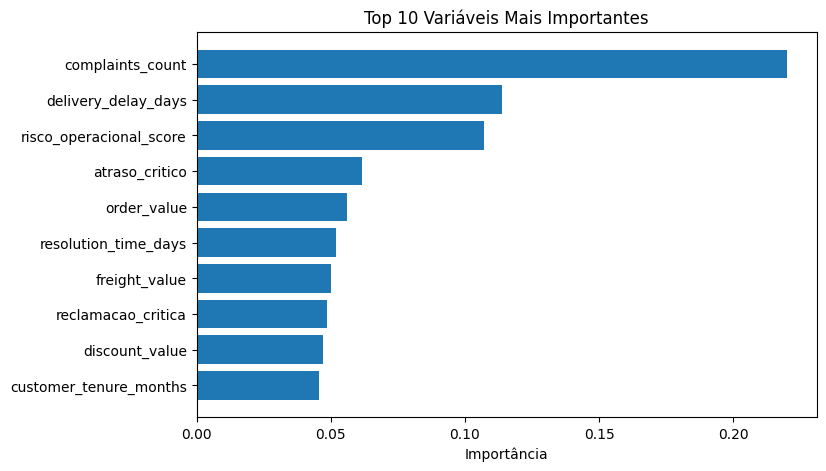

In [ ]:
# ==========================================================
# VISUALIZAÇÃO DAS VARIÁVEIS MAIS IMPORTANTES
# ==========================================================

import matplotlib.pyplot as plt

top10 = importancias.head(10)

plt.figure(figsize=(8,5))

plt.barh(
    top10["Variavel"],
    top10["Importancia"]
)

plt.title(
    "Top 10 Variáveis Mais Importantes"
)

plt.xlabel("Importância")

plt.gca().invert_yaxis()

plt.show()